# Random forest on curve fitting results 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
#from functions.analysis import *
pd.options.display.float_format = '{:.2f}'.format

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = False

#day = datetime.today().strftime('%Y-%m-%d')
day = '2025-01-31' #'2024-10-22'
sample =  'all' # 'randomsample500' 

In [2]:
# read timeseries fit results and stats

metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-11-26.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 5547
number of metadata: 203
number of fit parameter sets: 49923


In [3]:
# get other metadata from timeseries file
ts = pd.read_csv('data/HATCH_v1.5_clean.csv')
ts_metadata = ts[['ID', 'Spatial Scale', 'Region', 'Country Name', 'Technology Name',
       'Metric', 'Unit', 'Data Source', 'Variable']]

In [7]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

In [8]:
# 'technology' and 'tech_name' are unique identifiers for each time series,
# while 'Technology Name' is a field which gives the technology, for which several time series for different countries can exist

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, ts_metadata.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'ID')
print(len(full_table))
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))
#full_table

49867
49867
56319
49867


In [9]:
# correct internally inconsistent labels
full_table['Metric'] = full_table['Metric'].replace({'Annual production': 'Annual Production',
                                                     'Cumulative total capacity': 'Cumulative Total Capacity'})

In [11]:
# mask r_squared values outside of range
full_table['r_squared_masked'] = full_table['r_squared'].mask(full_table['r_squared'] < 0).mask(full_table['r_squared'] > 1)
full_table['adj_r_squared_masked'] = full_table['adj_r_squared'].mask(full_table['adj_r_squared'] < 0).mask(full_table['adj_r_squared'] > 1)

In [12]:
# Group similar 'metrics' together
group_metrics = {'Annual Production': 'annual',
                 'Cumulative Length': 'cumulative',
                 'Total Number': 'cumulative',
                'Cumulative Total Capacity': 'cumulative',
                'Total Length': 'cumulative',
                'Share of Households': 'share',
                'Net Total Capacity': 'cumulative',
                'Installed Capacity': 'cumulative',
                'Share of Population': 'share',
                'Computing Capacity': 'cumulative',
                'Share of Market': 'share',
                'Cumulative Rated Power': 'cumulative',
                'Cumulative Rated Capacity': 'cumulative',
                'Cumulative Acreage': 'cumulative',
                'Installed electricity capacity': 'cumulative',
                'Share of Boilers': 'share'}
full_table['metric_grouped'] = full_table['Metric'].map(group_metrics)

In [13]:
# convert numerical variables to numeric types and centralize
for yr_var in ['Year of Invention', 'Year of First Embodiment of Tech', 'FirstCommercialYr', 'Granularity Numerical', 'Material Use Numerical']:
    full_table[yr_var + '_numeric'] = pd.to_numeric(full_table[yr_var], errors='coerce')
    full_table[yr_var + '_numcent'] = full_table[yr_var + '_numeric'] - full_table[yr_var + '_numeric'].mean()

In [14]:
full_table['Need for Customization'] = full_table['Need for Customization'].replace({'Mass-Customized [2]': 'Mass-customized [2]'})

too_long_pat_label = 'General Tagging of New Technological Developments; General Tagging of Cross-Sectional Technologies Spanning over Several Sections of the IPC; Technical Subjects Covered by Former USPC Cross-Reference Art Collections [XRACs] and Digests'
full_table['Patent Category Name'] = full_table['Patent Category Name'].replace({too_long_pat_label: 'General Tagging'})

# Meta regression random forest

In [17]:
# import packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, GroupKFold, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import mean_squared_error, r2_score, classification_report
import shap

Select data for the model

In [31]:
# select variables

# outcome variable 
categorical_features = ['functional_form', 'Spatial Scale', 'Final Material Use', 'Need for Customization',
                        'Complexity', 'Type of Adopter',
       'Granularity', 'Technology Lifetime', 'Strict replacement', 'Broad replacement',
       'Feedstock', 'Category Type', 'Patent Category Name', 'metric_grouped' ]

numerical_features  = ['Material Use Numerical_numcent',
       'FirstCommercialYr_numcent']

# Make sure all categorical features are strings using .loc
for feature in categorical_features:
    df.loc[:, feature] = df.loc[:, feature].astype(str)

# Select all columns with categorical_features and numerical_features
selected_features= categorical_features + numerical_features

# Silvana: I guess not important for you, but sometimes relevant e.g. for hour of the day. the blog is also interesting in general 
# When using hour of the day, make sure to use a cyclic encoding! https://blog.davidkaleko.com/feature-engineering-cyclical-features.html

In [32]:
# this is the dataframe which should contain your dependant variable 
df_sample = full_table[['r_squared_masked'] + selected_features].dropna().copy()
print(len(df_sample))

32865


In [33]:
# to find the best paraMeterType, use a sample of the data 
# Silvana: here you assign the features into either X (controls) or y (dependent variable)
y = df_sample['r_squared_masked']
X = df_sample[selected_features]
#groups = df_sample['edc_id'] # acknowledging that the output for different individuals are correlated 

feature_list = list(X.columns)
print(X.columns) 

Index(['functional_form', 'Spatial Scale', 'Final Material Use',
       'Need for Customization', 'Complexity', 'Type of Adopter',
       'Granularity', 'Technology Lifetime', 'Strict replacement',
       'Broad replacement', 'Feedstock', 'Category Type',
       'Patent Category Name', 'metric_grouped',
       'Material Use Numerical_numcent', 'FirstCommercialYr_numcent'],
      dtype='object')


#### train model 

without hyperparameter tuning

In [34]:
# Silvana: without hyperparameter tuning is much faster 
# Silvana: generally, use pipeline

save_folder = 'results'

single_run = True
if single_run:
    # Preprocessing for numerical data (scaling)
    numeric_transformer = 'passthrough' #@Finn: in some models, numeric variables are standardized/normalized to mean zero and variance of 1. don't know why/when. Decided to leaf it as passthrough 
    # Pipeline(steps=[
    #     ('scaler', StandardScaler())
    # ]) # not needed, becuase scaling in random forests is not what I may need

    # The StandardScaler from sklearn.preprocessing standardizes features by removing the mean and scaling to unit variance. I do not need that here 
    # This means that each feature will be transformed such that it has a mean of 0 and a standard deviation of 1.
    # Purpose of numeric_transformer
    # By combining these steps in a pipeline, the numeric_transformer ensures consistent preprocessing of numerical data, which can improve the performance and stability of a machine learning model.


    # Preprocessing for categorical data (one-hot encoding)
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # If an unknown category is encountered during the transform phase, it will be ignored, and all-zeros will be assigned to that category.
    # This option is useful when the test data might include categories not seen during training, and you don't want your model to break upon encountering such data.

    # Combine preprocessing steps
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    #@Finn: only relevant becuase no hypoerparemter tuning is selected
    # paramaters
    n_estimators = 1000
    max_depth = 10 
    min_samples_split = 5
    min_samples_leaf = 10
    bootstrap = True 


    # Create a pipeline that first transforms data then fits a model
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators = n_estimators, 
            max_depth = max_depth, 
            min_samples_split = min_samples_split, 
            min_samples_leaf = min_samples_leaf, 
            bootstrap = bootstrap, 
            random_state=42, n_jobs=-1))  # @Finn: n_jobs = -1 means parallel computing using all available cores
        # Change the approach here, e.g., Decision Tree, XGBoost
        # Alternatively, set standard paraMeterTypes
        # hyperparaMeterType tuning (n_estimators (takes longer if larger) and random_state are called hyperparaMeterTypes)
        # XGBoost = gradient-based, how to find the minimum error fastest @Finn: XGBoost is a different ml model/alternative to random forest
    ])

    # # Cross-validation ----------------------------

    results = cross_val_score(model_pipeline, X, y, scoring='r2', n_jobs=2)

    # with groups:
    # group_kfold = GroupKFold(n_splits=5) # used for cross-validation. I use kfold because I have multiple regression coefficients from the same individual for mulitple years and I do not want the variable of one to predict itself
    # results = cross_val_score(model_pipeline, X, y, groups=groups, cv=group_kfold, scoring='r2', n_jobs=2)

    print(f"Cross-validated R² scores: {results}")
    print(f"Mean R² score: {results.mean()}")




Cross-validated R² scores: [0.13070556 0.28487245 0.34071744 0.31676277 0.3055853 ]
Mean R² score: 0.2757287026591215


ValueError: not enough values to unpack (expected 5, got 4)

In [36]:
if single_run:
    # Optional: Final evaluation on a single train-test split to confirm the performance
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # with groups: X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    # Calculate final Mean Squared Error on the test set
    final_mse = mean_squared_error(y_test, y_pred)
    print(f"Final Mean Squared Error on Test Set: {final_mse}")

    # Calculate final R² score on the test set
    final_r2 = r2_score(y_test, y_pred)
    print(f"Final R² on Test Set: {final_r2}")

Final Mean Squared Error on Test Set: 0.06860438437606112
Final R² on Test Set: 0.3424650747759135


In [ ]:
# Silvana: highly recommend to include saving option of the model to use for further reference
save_model_pipeline(
    folder_name=save_folder,
    model=model_pipeline,
    X=X,
    y=y,
    hyperparameters={
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'bootstrap': bootstrap,
    },
    feature_info={
        "numerical_features": numerical_features,
        "categorical_features": categorical_features,
    }, 
    X_train = X_train, 
    X_test = X_test, 
    y_train = y_train, 
    y_test = y_test,
)

with hyperparameter tuning 


In [ ]:

# Preprocessing for numerical data (scaling)
numeric_transformer = 'passthrough'
# Pipeline(steps=[
#     ('scaler', StandardScaler())
# ]) # not needed, becuase scaling in random forests is not what I may need

# The StandardScaler from sklearn.preprocessing standardizes features by removing the mean and scaling to unit variance. I do not need that here 
# This means that each feature will be transformed such that it has a mean of 0 and a standard deviation of 1.
# Purpose of numeric_transformer
# By combining these steps in a pipeline, the numeric_transformer ensures consistent preprocessing of numerical data, which can improve the performance and stability of a machine learning model.


# Preprocessing for categorical data (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# If an unknown category is encountered during the transform phase, it will be ignored, and all-zeros will be assigned to that category.
# This option is useful when the test data might include categories not seen during training, and you don't want your model to break upon encountering such data.

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Create a pipeline that first transforms data then fits a model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))  
    # Change the approach here, e.g., Decision Tree, XGBoost
    # Alternatively, set standard paraMeterTypes
    # hyperparaMeterType tuning (n_estimators (takes longer if larger) and random_state are called hyperparaMeterTypes)
    # XGBoost = gradient-based, how to find the minimum error fastest
])


# Set up GroupKFold
# with groups: group_kfold = GroupKFold(n_splits=5)


# # Cross-validation ----------------------------

# model_pipeline.get_params()

# 1. grid serach  
# Define the hyperparaMeterType grid
param_grid = {
    'regressor__n_estimators': [500,1000], # in paper: 100,500,
    'regressor__max_depth': [None, 10, 15],
    'regressor__min_samples_split': [5, 10],# in paper: 2, 
    'regressor__min_samples_leaf': [5,10], # in paper 1,
}

# Set up GridSearchCV
search = GridSearchCV(estimator=model_pipeline, param_grid=param_grid, scoring='r2', refit = True, n_jobs=-1)
# with groups: search = GridSearchCV(estimator=model_pipeline, param_grid=param_grid, cv=group_kfold, scoring='r2', refit = True, n_jobs=-1)
# Use R² if you want to understand the proportion of the variance explained by the model. It provides a normalized metric that can be easier to interpret in terms of "percentage of variance explained."



# 2. Randomized Search @Finn: better control of number of parameters that are being tested

# param_distributions = {
#     'regressor__bootstrap':[True, False],
#     'regressor__n_estimators': list(range(500, 2000,100)),
#     'regressor__max_depth': [None] + list(range(5, 20,5)),
#     'regressor__min_samples_split': list(range(2, 100,5)),
# }


# search = RandomizedSearchCV(estimator=model_pipeline, 
#                                    param_distributions=param_distributions, 
#                                    cv=group_kfold, 
#                                    scoring='r2', 
#                                    n_jobs = -1, 
#                                    refit=True, 
#                                    n_iter=30,  # Number of paraMeterType settings that are sampled
#                                    random_state=42)

# Fit RandomizedSearchCV
search.fit(X, y)
# with groups: search.fit(X, y, groups=groups)

# Extract best paraMeterTypes and best score
best_params = search.best_params_
best_score = search.best_score_

print(f"Best ParaMeterTypes: {best_params}")
print(f"Best R²: {best_score}")

# Optional: Final evaluation on a single train-test split to confirm the performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# with groups: X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

model_retrained = search.best_estimator_  # This is the best pipeline already refitted: SELECT for gridsearch
#model_retrained = random_search.best_estimator_  # This is the best pipeline already refitted

y_pred = model_retrained.predict(X_test)

# Calculate final Mean Squared Error on the test set
final_mse = mean_squared_error(y_test, y_pred)
print(f"Final Mean Squared Error on Test Set: {final_mse}")

# Calculate final R² score on the test set
final_r2 = r2_score(y_test, y_pred)
print(f"Final R² on Test Set: {final_r2}")


Best ParaMeterTypes: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 1000}
Best R²: 0.0402386647584533
Final Mean Squared Error on Test Set: 0.2806797937764804
Final R² on Test Set: 0.10197828686734789
Model, data, and metadata saved in output/all_2024/


In [ ]:

save_model_pipeline(
    folder_name=folder,
    model=model_retrained,
    X=X,
    y=y,
    hyperparameters=search.best_params_,
    feature_info={
        "numerical_features": numerical_features,
        "categorical_features": categorical_features,
    }, 
    X_train = X_train, 
    X_test = X_test, 
    y_train = y_train, 
    y_test = y_test,
)

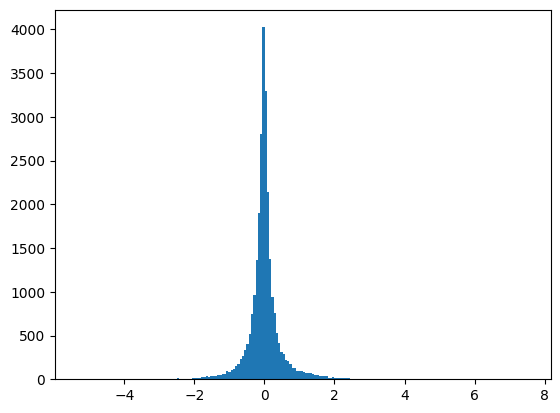

Saved Residuals Histogram at output/all_2024//residuals_histogram.png


In [ ]:
residuals = y_test - y_pred
plt.hist(residuals, bins=200)
residuals_plot_path = f'{folder}/residuals_histogram.png'  # Path to save the residuals plot
plt.savefig(residuals_plot_path)
plt.show()  # Display the plot

print(f"Saved Residuals Histogram at {residuals_plot_path}")